<a href="https://colab.research.google.com/github/CaptainMarlow/IAD_labs/blob/main/cnn_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import os
import urllib.request
import zipfile
import time
import cv2

Приклад даних:
         Name        all_types
0   bulbasaur  [Grass, Poison]
1     ivysaur  [Grass, Poison]
2    venusaur  [Grass, Poison]
3  charmander           [Fire]
4  charmeleon           [Fire]

Унікальні класи (18): ['Bug' 'Dark' 'Dragon' 'Electric' 'Fairy' 'Fighting' 'Fire' 'Flying'
 'Ghost' 'Grass' 'Ground' 'Ice' 'Normal' 'Poison' 'Psychic' 'Rock' 'Steel'
 'Water']
Found 647 validated image filenames.
Found 162 validated image filenames.
Завантаження зображень у пам'ять.

Починаємо навчання...
Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 282ms/step - binary_accuracy: 0.8204 - loss: 0.4437 - val_binary_accuracy: 0.9170 - val_loss: 0.2870
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - binary_accuracy: 0.9058 - loss: 0.3233 - val_binary_accuracy: 0.9170 - val_loss: 0.2822
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - binary_accuracy: 0.9103 - loss: 0.3208 - val_binary_accuracy: 0.9170 - val_loss: 0.2823
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - binary_

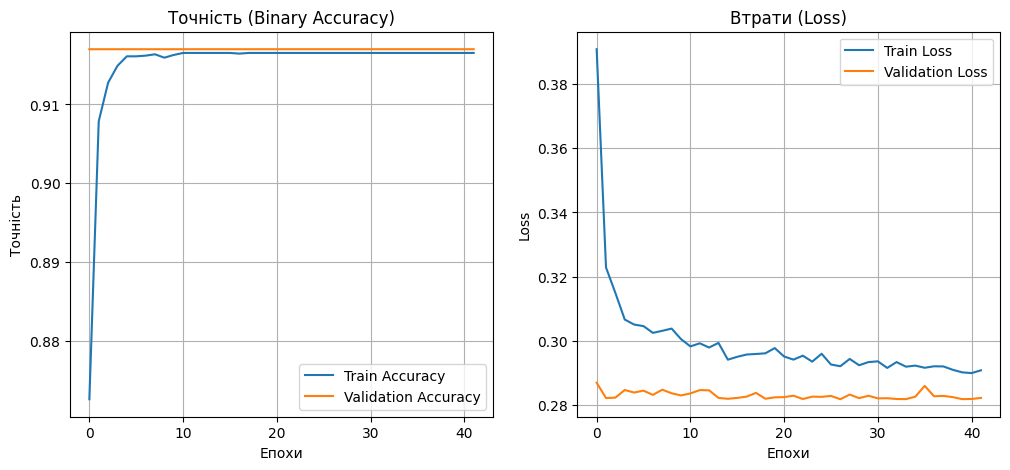

In [8]:
base_path = '/content/drive/MyDrive/Colab Notebooks/'
csv_path = os.path.join(base_path, 'pokemon.csv')
images_folder = os.path.join(base_path, 'images')

df = pd.read_csv(csv_path)

# 1.1. Формування шляхів до файлів
def get_filename(name):
    return f"{name}.png"

df['filename'] = df['Name'].apply(get_filename)
df['file_path'] = df['filename'].apply(lambda x: os.path.join(images_folder, x))
df = df[df['file_path'].apply(os.path.exists)]

# 1.2. ПІДГОТОВКА МУЛЬТИЛЕЙБЛІВ
df['Type2'] = df['Type2'].fillna('None')

def combine_types(row):
    types = [row['Type1']]
    if row['Type2'] != 'None':
        types.append(row['Type2'])
    return types

df['all_types'] = df.apply(combine_types, axis=1)

print(f"Приклад даних:\n{df[['Name', 'all_types']].head()}")
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df['all_types'])
classes = mlb.classes_
print(f"\nУнікальні класи ({len(classes)}): {classes}")

train_idx, val_idx = train_test_split(df.index, test_size=0.2, random_state=42, stratify=df['Type1'])

train_df = df.loc[train_idx]
val_df = df.loc[val_idx]

y_train = y[train_idx]
y_val = y[val_idx]

# ================
# 2. ГЕНЕРАТОРИ
# ================
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 32

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=images_folder,
    x_col="filename",
    y_col=None,
    target_size=(120, 120),
    batch_size=batch_size,
    class_mode=None,
    shuffle=False
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=images_folder,
    x_col="filename",
    y_col=None,
    target_size=(120, 120),
    batch_size=batch_size,
    class_mode=None,
    shuffle=False
)


def multi_label_generator(generator, y_labels):
    while True:
        idx = generator.index_array
        batch_x = generator.next()
        pass

def load_images(df, folder, size=(120, 120)):
    images = []
    for fname in df['filename']:
        img_path = os.path.join(folder, fname)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        images.append(img)
    return np.array(images)

print("Завантаження зображень у пам'ять.")
X_train_data = load_images(train_df, images_folder)
X_val_data = load_images(val_df, images_folder)

# Нормалізація
X_train_data = X_train_data.astype('float32') / 255.0
X_val_data = X_val_data.astype('float32') / 255.0

train_gen_flow = datagen.flow(X_train_data, y_train, batch_size=32)
val_gen_flow = val_datagen.flow(X_val_data, y_val, batch_size=32)


# ==============
# 3. МОДЕЛЬ (VGG16 + SIGMOID)
# ==============
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(120, 120, 3))
base_model.trainable = False

model = keras.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(classes), activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

# ===========
# 4. НАВЧАННЯ
# ===========
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

print("\nПочинаємо навчання...")
history = model.fit(
    train_gen_flow,
    epochs=150,
    validation_data=val_gen_flow,
    callbacks=[early_stopping]
)

# ==========
# 5. ГРАФІКИ
# ==========
acc_key = 'binary_accuracy'
val_acc_key = 'val_binary_accuracy'

plt.figure(figsize=(12, 5))

# Графік точності
plt.subplot(1, 2, 1)
plt.plot(history.history[acc_key], label='Train Accuracy')
plt.plot(history.history[val_acc_key], label='Validation Accuracy')
plt.title('Точність (Binary Accuracy)')
plt.xlabel('Епохи')
plt.ylabel('Точність')
plt.legend()
plt.grid(True)

# Графік втрат
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Втрати (Loss)')
plt.xlabel('Епохи')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

Навчання рукотворної CNN
Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 288ms/step - binary_accuracy: 0.8075 - loss: 0.5591 - val_binary_accuracy: 0.9170 - val_loss: 0.3070
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - binary_accuracy: 0.9076 - loss: 0.3252 - val_binary_accuracy: 0.9170 - val_loss: 0.2849
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - binary_accuracy: 0.9136 - loss: 0.3129 - val_binary_accuracy: 0.9170 - val_loss: 0.2828
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - binary_accuracy: 0.9138 - loss: 0.3092 - val_binary_accuracy: 0.9170 - val_loss: 0.2833
Epoch 5/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - binary_accuracy: 0.9162 - loss: 0.3012 - val_binary_accuracy: 0.9170 - val_loss: 0.2819
Epoch 6/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - binary_accuracy: 0.9193 - loss: 0.2932 - val_binary_accuracy: 0.9170 - val_loss: 0.2833
Epoch 7/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - binary_accuracy: 0.9165 - loss: 0.2997 - val_binary_accuracy: 

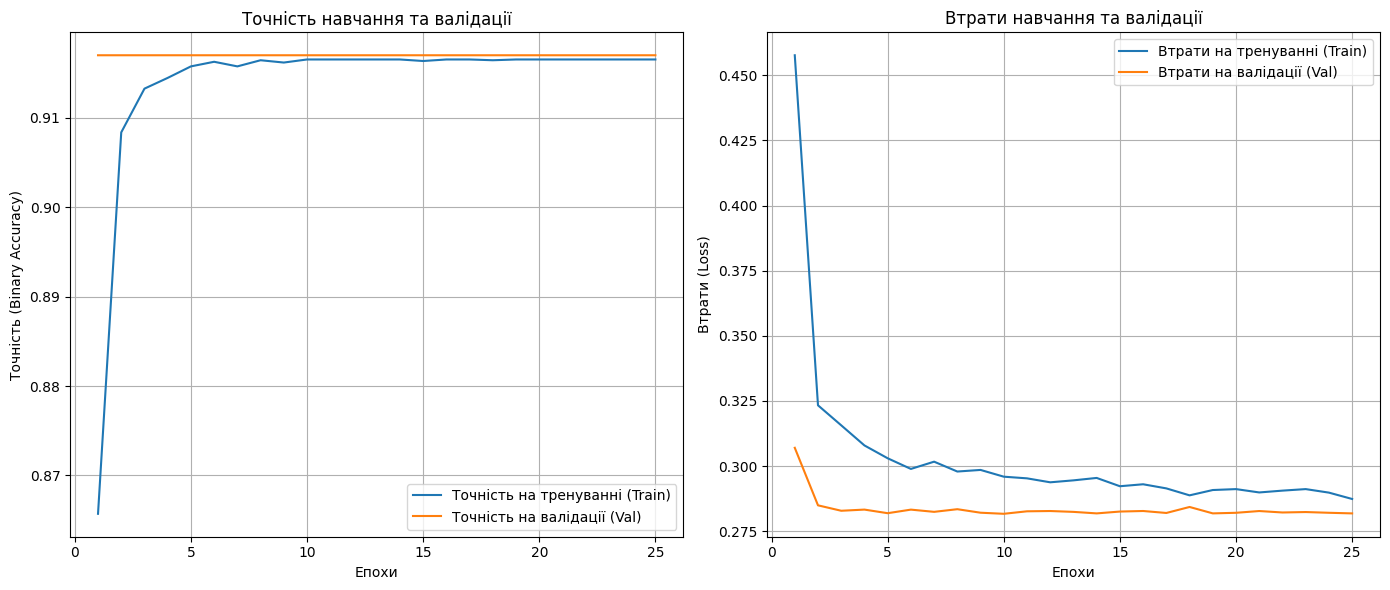

In [10]:
manual_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(120, 120, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(classes), activation='sigmoid')
])

manual_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

print("Навчання рукотворної CNN")

simple_history = manual_model.fit(
    train_gen_flow,
    epochs=150,
    validation_data=val_gen_flow,
    callbacks=[early_stopping]
)

acc = simple_history.history['binary_accuracy']
val_acc = simple_history.history['val_binary_accuracy']
loss = simple_history.history['loss']
val_loss = simple_history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Точність на тренуванні (Train)')
plt.plot(epochs_range, val_acc, label='Точність на валідації (Val)')
plt.title('Точність навчання та валідації')
plt.xlabel('Епохи')
plt.ylabel('Точність (Binary Accuracy)')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Втрати на тренуванні (Train)')
plt.plot(epochs_range, val_loss, label='Втрати на валідації (Val)')
plt.title('Втрати навчання та валідації')
plt.xlabel('Епохи')
plt.ylabel('Втрати (Loss)')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

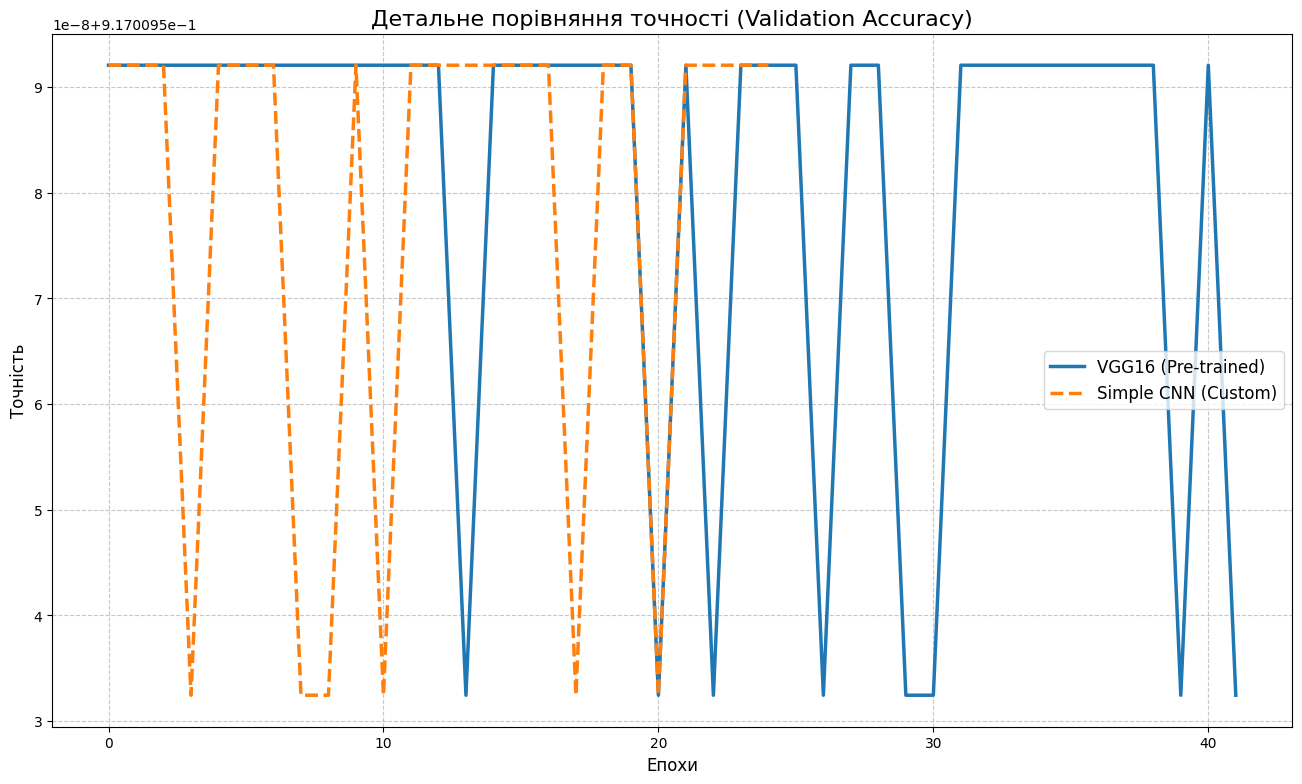

In [13]:
plt.figure(figsize=(16, 9))


val_acc_vgg = history.history['val_binary_accuracy']
val_acc_simple = simple_history.history['val_binary_accuracy']

plt.plot(val_acc_vgg, label='VGG16 (Pre-trained)', linewidth=2.5)
plt.plot(val_acc_simple, label='Simple CNN (Custom)', linewidth=2.5, linestyle='--')

plt.title('Детальне порівняння точності (Validation Accuracy)', fontsize=16)
plt.xlabel('Епохи', fontsize=12)
plt.ylabel('Точність', fontsize=12)
plt.legend(fontsize=12)


plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.show()

На цьому графіку варто звернути увагу на масштаб, оскільки це масштаб досить дрібний можна сказати що вручну створена модель також досить непогана.